In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn 


In [3]:
df = pd.read_csv("C:/Users/Batman/Documents/WGUData/churn_raw_data.csv")

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 52 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Unnamed: 0            10000 non-null  int64  
 1   CaseOrder             10000 non-null  int64  
 2   Customer_id           10000 non-null  object 
 3   Interaction           10000 non-null  object 
 4   City                  10000 non-null  object 
 5   State                 10000 non-null  object 
 6   County                10000 non-null  object 
 7   Zip                   10000 non-null  int64  
 8   Lat                   10000 non-null  float64
 9   Lng                   10000 non-null  float64
 10  Population            10000 non-null  int64  
 11  Area                  10000 non-null  object 
 12  Timezone              10000 non-null  object 
 13  Job                   10000 non-null  object 
 14  Children              7505 non-null   float64
 15  Age                 

In [5]:
df.duplicated()  # Used to determine which columns have duplicates. False indicates that the column has no duplicate

0       False
1       False
2       False
3       False
4       False
        ...  
9995    False
9996    False
9997    False
9998    False
9999    False
Length: 10000, dtype: bool

In [6]:
print(df.duplicated().value_counts()) # Counts number of duplicates. No duplicate values discovered 

False    10000
Name: count, dtype: int64


In [7]:
df.drop_duplicates()
df = df.drop_duplicates()  # would be used to discard dupliucate values, had they been discovered. 

In [8]:
print(df.drop_duplicates().value_counts()) #identifies the count of each unique occurence

Unnamed: 0  CaseOrder  Customer_id  Interaction                           City         State  County      Zip    Lat       Lng         Population  Area      Timezone                      Job                       Children  Age   Education                                 Employment  Income    Marital        Gender  Churn  Outage_sec_perweek  Email  Contacts  Yearly_equip_failure  Techie  Contract        Port_modem  Tablet  InternetService  Phone  Multiple  OnlineSecurity  OnlineBackup  DeviceProtection  TechSupport  StreamingTV  StreamingMovies  PaperlessBilling  PaymentMethod             Tenure     MonthlyCharge  Bandwidth_GB_Year  item1  item2  item3  item4  item5  item6  item7  item8
2           2          S120509      fb76459f-c047-4a9d-8af9-e0f7d4ac2524  West Branch  MI     Ogemaw      48661  44.32893  -84.24080   10446       Urban     America/Detroit               Programmer, multimedia    1.0       27.0  Regular High School Diploma               Retired     21704.77  Married     

In [9]:
df.isnull().sum() # counts the amount of missing values in each column. 

Unnamed: 0                 0
CaseOrder                  0
Customer_id                0
Interaction                0
City                       0
State                      0
County                     0
Zip                        0
Lat                        0
Lng                        0
Population                 0
Area                       0
Timezone                   0
Job                        0
Children                2495
Age                     2475
Education                  0
Employment                 0
Income                  2490
Marital                    0
Gender                     0
Churn                      0
Outage_sec_perweek         0
Email                      0
Contacts                   0
Yearly_equip_failure       0
Techie                  2477
Contract                   0
Port_modem                 0
Tablet                     0
InternetService         2129
Phone                   1026
Multiple                   0
OnlineSecurity             0
OnlineBackup  

In [10]:
import missingno as msno # imports missingno

<Axes: >

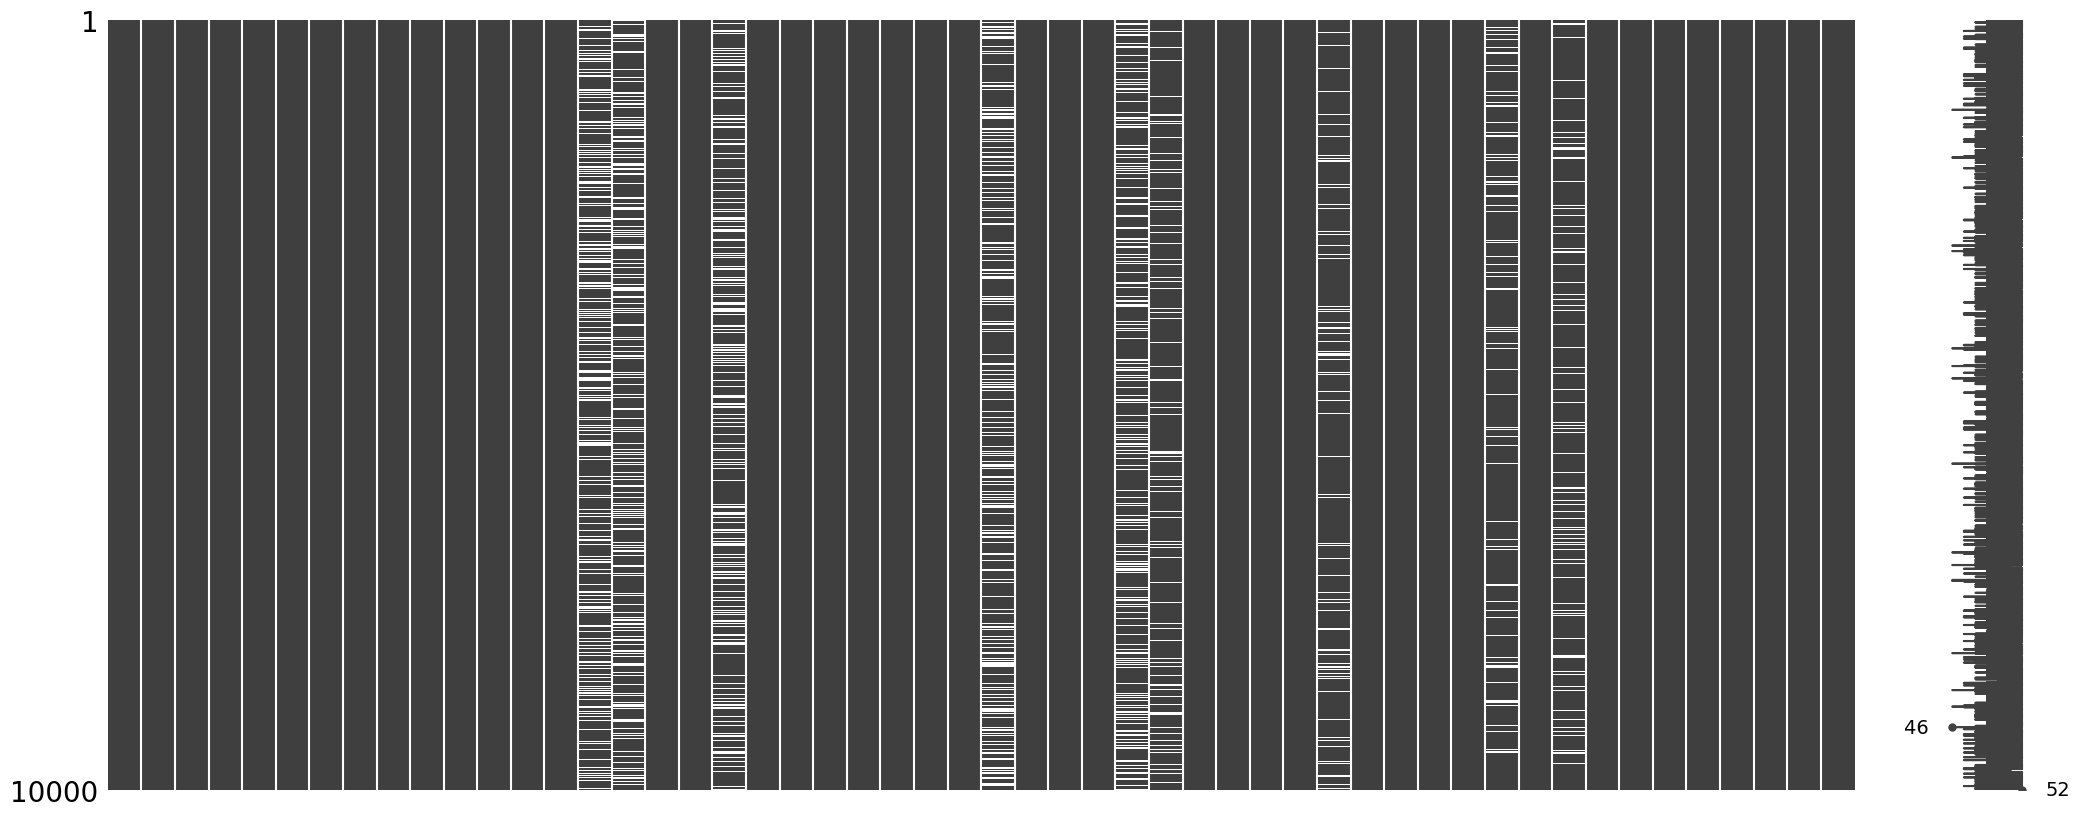

In [11]:
msno.matrix(df) # visializes the missing data

(array([1919., 1874., 1100., 1096.,  769.,  161.,  135.,  149.,  158.,
         144.]),
 array([ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10.]),
 <BarContainer object of 10 artists>)

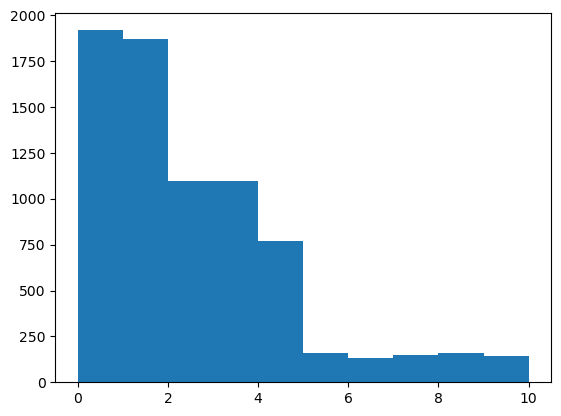

In [12]:
plt.hist(df['Children']) # plots a histogram for the defined category. 

(array([853., 756., 714., 739., 708., 739., 728., 728., 761., 799.]),
 array([18. , 25.1, 32.2, 39.3, 46.4, 53.5, 60.6, 67.7, 74.8, 81.9, 89. ]),
 <BarContainer object of 10 artists>)

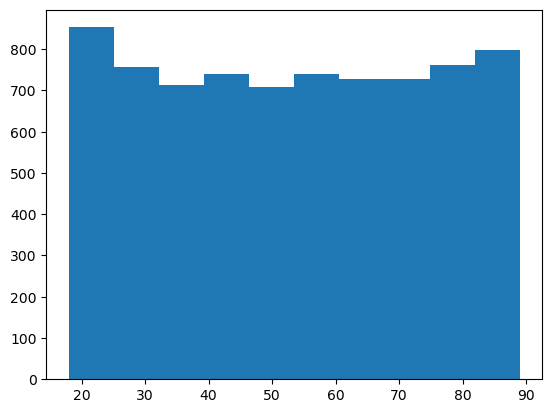

In [13]:
plt.hist(df['Age'])

(array([2.912e+03, 2.642e+03, 1.193e+03, 5.080e+02, 1.670e+02, 6.000e+01,
        2.100e+01, 4.000e+00, 1.000e+00, 2.000e+00]),
 array([   740.66 ,  26556.664,  52372.668,  78188.672, 104004.676,
        129820.68 , 155636.684, 181452.688, 207268.692, 233084.696,
        258900.7  ]),
 <BarContainer object of 10 artists>)

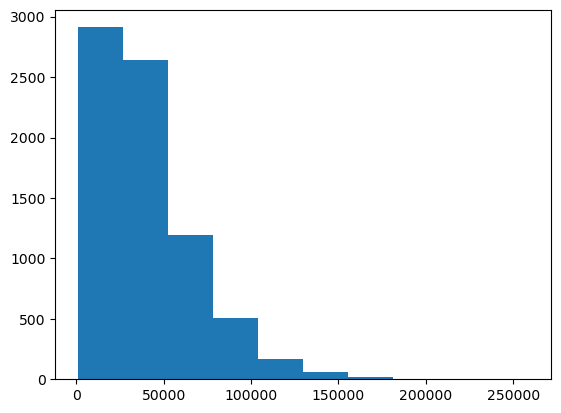

In [14]:
plt.hist(df['Income'])

(array([1031., 2062., 1087.,  255.,   98.,  370.,  844., 1399., 1484.,
         349.]),
 array([ 155.5067148 ,  855.85424332, 1556.20177184, 2256.54930036,
        2956.89682888, 3657.2443574 , 4357.59188592, 5057.93941444,
        5758.28694296, 6458.63447148, 7158.982     ]),
 <BarContainer object of 10 artists>)

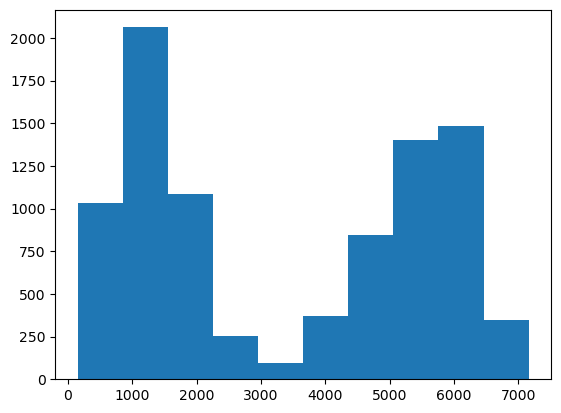

In [15]:
plt.hist(df['Bandwidth_GB_Year'])

(array([2337., 1473.,  568.,  132.,   30.,  221.,  540.,  870., 1330.,
        1568.]),
 array([ 1.00025934,  8.10016141, 15.20006347, 22.29996554, 29.3998676 ,
        36.49976967, 43.59967174, 50.6995738 , 57.79947587, 64.89937793,
        71.99928   ]),
 <BarContainer object of 10 artists>)

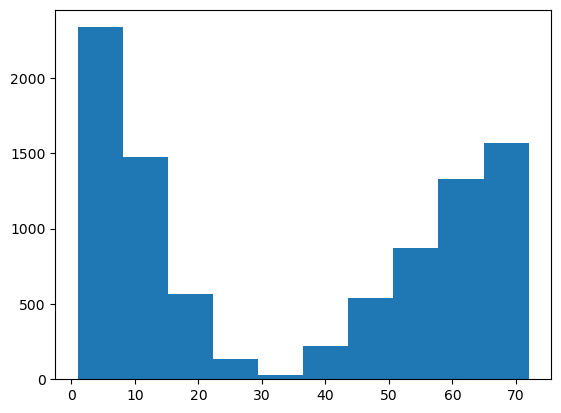

In [16]:
plt.hist(df['Tenure'])

In [17]:
mapping_dict = {'No': 0, 'Yes': 1}
df['Techie'] = df ['Techie'].replace(mapping_dict)       #Allows me to turn categorical data into nummerical data. This would allow me to then plot values in a histogram.     
print(df.head())

   Unnamed: 0  CaseOrder Customer_id                           Interaction  \
0           1          1     K409198  aa90260b-4141-4a24-8e36-b04ce1f4f77b   
1           2          2     S120509  fb76459f-c047-4a9d-8af9-e0f7d4ac2524   
2           3          3     K191035  344d114c-3736-4be5-98f7-c72c281e2d35   
3           4          4      D90850  abfa2b40-2d43-4994-b15a-989b8c79e311   
4           5          5     K662701  68a861fd-0d20-4e51-a587-8a90407ee574   

          City State                 County    Zip       Lat        Lng  ...  \
0  Point Baker    AK  Prince of Wales-Hyder  99927  56.25100 -133.37571  ...   
1  West Branch    MI                 Ogemaw  48661  44.32893  -84.24080  ...   
2      Yamhill    OR                Yamhill  97148  45.35589 -123.24657  ...   
3      Del Mar    CA              San Diego  92014  32.96687 -117.24798  ...   
4    Needville    TX              Fort Bend  77461  29.38012  -95.80673  ...   

   MonthlyCharge Bandwidth_GB_Year item1 item2  it

C:\Users\Batman\AppData\Local\Temp\ipykernel_26784\2254928419.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Techie'] = df ['Techie'].replace(mapping_dict)       #Allows me to turn categorical data into nummerical data. This would allow me to then plot values in a histogram.


(array([6266.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,
        1257.]),
 array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ]),
 <BarContainer object of 10 artists>)

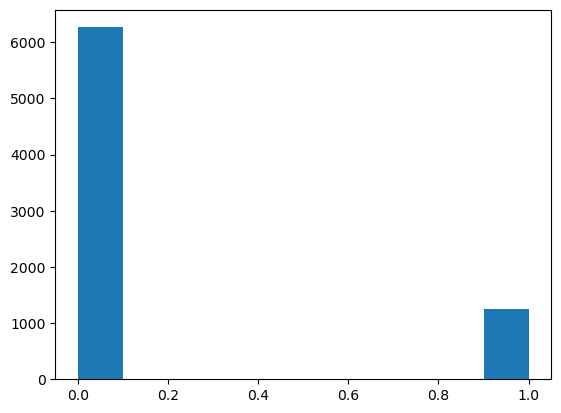

In [18]:
plt.hist(df['Techie']) #Histogram of categorical data after converting it to a numerical form. 

In [19]:
mapping_dict = {'DSL': 0, 'Fiber Optic': 1}
df['InternetService'] = df ['InternetService'].replace(mapping_dict)           
print(df.head())

   Unnamed: 0  CaseOrder Customer_id                           Interaction  \
0           1          1     K409198  aa90260b-4141-4a24-8e36-b04ce1f4f77b   
1           2          2     S120509  fb76459f-c047-4a9d-8af9-e0f7d4ac2524   
2           3          3     K191035  344d114c-3736-4be5-98f7-c72c281e2d35   
3           4          4      D90850  abfa2b40-2d43-4994-b15a-989b8c79e311   
4           5          5     K662701  68a861fd-0d20-4e51-a587-8a90407ee574   

          City State                 County    Zip       Lat        Lng  ...  \
0  Point Baker    AK  Prince of Wales-Hyder  99927  56.25100 -133.37571  ...   
1  West Branch    MI                 Ogemaw  48661  44.32893  -84.24080  ...   
2      Yamhill    OR                Yamhill  97148  45.35589 -123.24657  ...   
3      Del Mar    CA              San Diego  92014  32.96687 -117.24798  ...   
4    Needville    TX              Fort Bend  77461  29.38012  -95.80673  ...   

   MonthlyCharge Bandwidth_GB_Year item1 item2  it

C:\Users\Batman\AppData\Local\Temp\ipykernel_26784\1781358301.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['InternetService'] = df ['InternetService'].replace(mapping_dict)


(array([3463.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,
        4408.]),
 array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ]),
 <BarContainer object of 10 artists>)

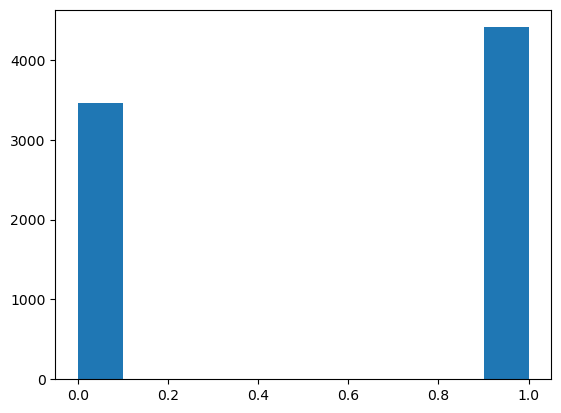

In [20]:
plt.hist(df['InternetService'])

In [21]:
mapping_dict = {'No': 0, 'Yes': 1}
df['Phone'] = df ['Phone'].replace(mapping_dict)           
print(df.head())

   Unnamed: 0  CaseOrder Customer_id                           Interaction  \
0           1          1     K409198  aa90260b-4141-4a24-8e36-b04ce1f4f77b   
1           2          2     S120509  fb76459f-c047-4a9d-8af9-e0f7d4ac2524   
2           3          3     K191035  344d114c-3736-4be5-98f7-c72c281e2d35   
3           4          4      D90850  abfa2b40-2d43-4994-b15a-989b8c79e311   
4           5          5     K662701  68a861fd-0d20-4e51-a587-8a90407ee574   

          City State                 County    Zip       Lat        Lng  ...  \
0  Point Baker    AK  Prince of Wales-Hyder  99927  56.25100 -133.37571  ...   
1  West Branch    MI                 Ogemaw  48661  44.32893  -84.24080  ...   
2      Yamhill    OR                Yamhill  97148  45.35589 -123.24657  ...   
3      Del Mar    CA              San Diego  92014  32.96687 -117.24798  ...   
4    Needville    TX              Fort Bend  77461  29.38012  -95.80673  ...   

   MonthlyCharge Bandwidth_GB_Year item1 item2  it

C:\Users\Batman\AppData\Local\Temp\ipykernel_26784\122324756.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Phone'] = df ['Phone'].replace(mapping_dict)


(array([ 846.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,
        8128.]),
 array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ]),
 <BarContainer object of 10 artists>)

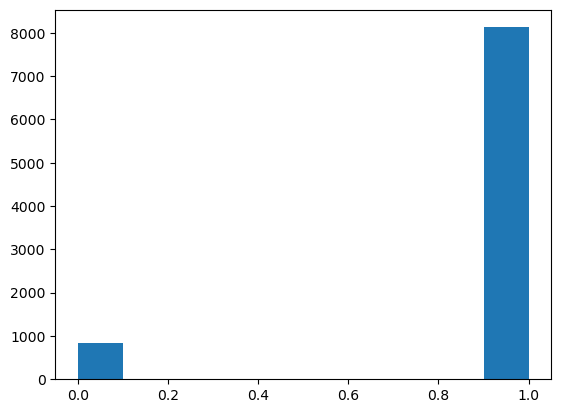

In [22]:
plt.hist(df['Phone'])

In [23]:
mapping_dict = {'No': 0, 'Yes': 1}
df['TechSupport'] = df ['TechSupport'].replace(mapping_dict)           
print(df.head())

   Unnamed: 0  CaseOrder Customer_id                           Interaction  \
0           1          1     K409198  aa90260b-4141-4a24-8e36-b04ce1f4f77b   
1           2          2     S120509  fb76459f-c047-4a9d-8af9-e0f7d4ac2524   
2           3          3     K191035  344d114c-3736-4be5-98f7-c72c281e2d35   
3           4          4      D90850  abfa2b40-2d43-4994-b15a-989b8c79e311   
4           5          5     K662701  68a861fd-0d20-4e51-a587-8a90407ee574   

          City State                 County    Zip       Lat        Lng  ...  \
0  Point Baker    AK  Prince of Wales-Hyder  99927  56.25100 -133.37571  ...   
1  West Branch    MI                 Ogemaw  48661  44.32893  -84.24080  ...   
2      Yamhill    OR                Yamhill  97148  45.35589 -123.24657  ...   
3      Del Mar    CA              San Diego  92014  32.96687 -117.24798  ...   
4    Needville    TX              Fort Bend  77461  29.38012  -95.80673  ...   

   MonthlyCharge Bandwidth_GB_Year item1 item2  it

C:\Users\Batman\AppData\Local\Temp\ipykernel_26784\288230424.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['TechSupport'] = df ['TechSupport'].replace(mapping_dict)


(array([5635.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,
        3374.]),
 array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ]),
 <BarContainer object of 10 artists>)

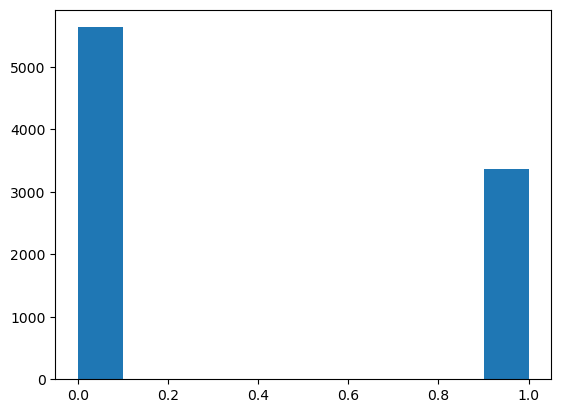

In [24]:
plt.hist(df['TechSupport'])

In [25]:
df['Children'].fillna(df['Children'].median(), inplace=True) #This function uses the median to replace the missing values. The median is best used for skewed data. 

C:\Users\Batman\AppData\Local\Temp\ipykernel_26784\3641708257.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Children'].fillna(df['Children'].median(), inplace=True) #This function uses the median to replace the missing values. The median is best used for skewed data.


(array([1919., 4369., 1100., 1096.,  769.,  161.,  135.,  149.,  158.,
         144.]),
 array([ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10.]),
 <BarContainer object of 10 artists>)

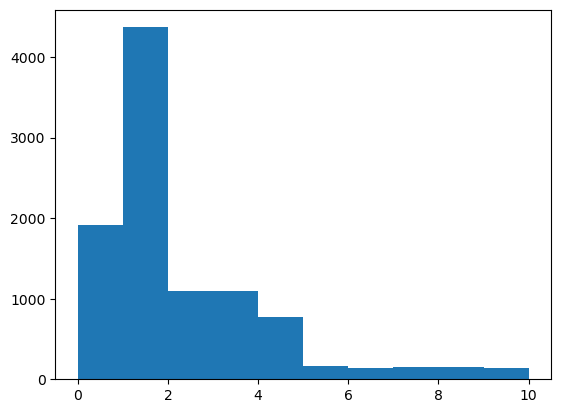

In [26]:
plt.hist(df['Children']) #Histogram of Children category after missing data has been replaced.

In [27]:
df['Age'].fillna(df['Age'].mean(), inplace=True) #This function fills in missing data for Age category with the mean. The mean is best used for imputation on symmetrical or evenly distributed data

C:\Users\Batman\AppData\Local\Temp\ipykernel_26784\732196866.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].mean(), inplace=True) #This function fills in missing data for Age category with the mean. The mean is best used for imputation on symmetrical or evenly distributed data


(array([ 853.,  756.,  714.,  739., 3183.,  739.,  728.,  728.,  761.,
         799.]),
 array([18. , 25.1, 32.2, 39.3, 46.4, 53.5, 60.6, 67.7, 74.8, 81.9, 89. ]),
 <BarContainer object of 10 artists>)

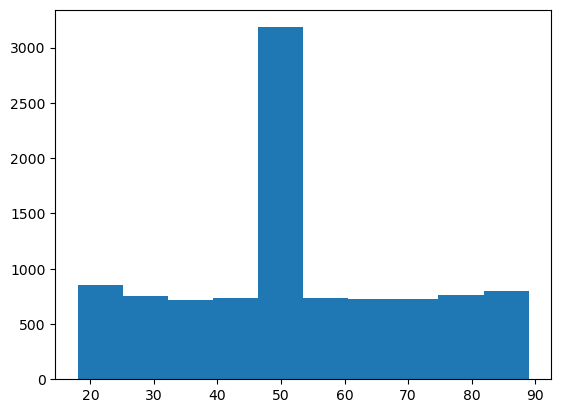

In [28]:
plt.hist(df['Age'])

In [29]:
df['Income'].fillna(df['Income'].median(), inplace=True)

C:\Users\Batman\AppData\Local\Temp\ipykernel_26784\1959487941.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Income'].fillna(df['Income'].median(), inplace=True)


(array([2.912e+03, 5.132e+03, 1.193e+03, 5.080e+02, 1.670e+02, 6.000e+01,
        2.100e+01, 4.000e+00, 1.000e+00, 2.000e+00]),
 array([   740.66 ,  26556.664,  52372.668,  78188.672, 104004.676,
        129820.68 , 155636.684, 181452.688, 207268.692, 233084.696,
        258900.7  ]),
 <BarContainer object of 10 artists>)

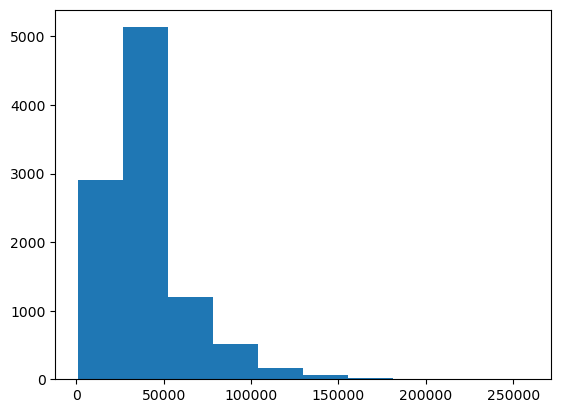

In [30]:
plt.hist(df['Income'])

In [31]:
df['Bandwidth_GB_Year'].fillna(df['Bandwidth_GB_Year'].mean(),inplace=True)

C:\Users\Batman\AppData\Local\Temp\ipykernel_26784\3937635782.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Bandwidth_GB_Year'].fillna(df['Bandwidth_GB_Year'].mean(),inplace=True)


(array([1031., 2062., 1087.,  255., 1119.,  370.,  844., 1399., 1484.,
         349.]),
 array([ 155.5067148 ,  855.85424332, 1556.20177184, 2256.54930036,
        2956.89682888, 3657.2443574 , 4357.59188592, 5057.93941444,
        5758.28694296, 6458.63447148, 7158.982     ]),
 <BarContainer object of 10 artists>)

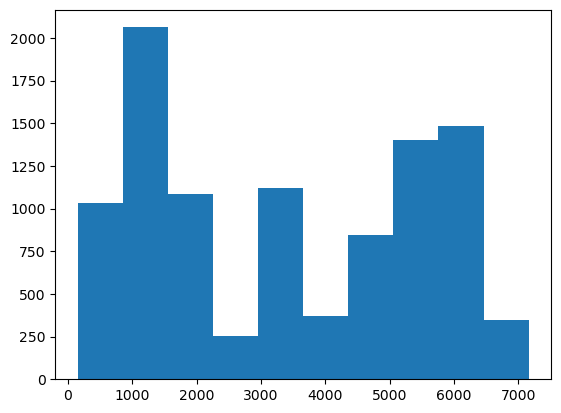

In [32]:
plt.hist(df['Bandwidth_GB_Year'])

In [33]:
df['Tenure'].fillna(df['Tenure'].mean(),inplace=True)

C:\Users\Batman\AppData\Local\Temp\ipykernel_26784\2355138603.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Tenure'].fillna(df['Tenure'].mean(),inplace=True)


(array([2337., 1473.,  568.,  132.,  961.,  221.,  540.,  870., 1330.,
        1568.]),
 array([ 1.00025934,  8.10016141, 15.20006347, 22.29996554, 29.3998676 ,
        36.49976967, 43.59967174, 50.6995738 , 57.79947587, 64.89937793,
        71.99928   ]),
 <BarContainer object of 10 artists>)

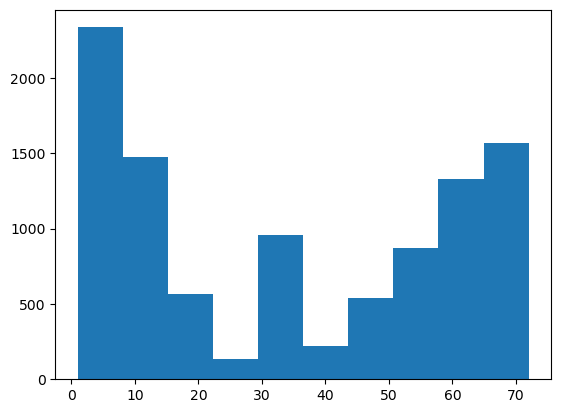

In [34]:
plt.hist(df['Tenure'])

In [35]:
df['InternetService'].fillna(df['InternetService'].mode()[0], inplace=True) #Mode was used to impute missing data in categorcal sections.

C:\Users\Batman\AppData\Local\Temp\ipykernel_26784\3993055952.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['InternetService'].fillna(df['InternetService'].mode()[0], inplace=True) #Mode was used to impute missing data in categorcal sections.


(array([3463.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,
        6537.]),
 array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ]),
 <BarContainer object of 10 artists>)

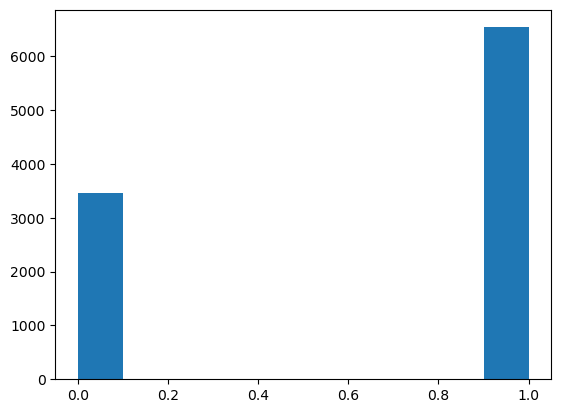

In [36]:
plt.hist(df['InternetService'])

In [37]:
df['Phone'].fillna(df['Phone'].mode()[0], inplace=True)

C:\Users\Batman\AppData\Local\Temp\ipykernel_26784\3766259288.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Phone'].fillna(df['Phone'].mode()[0], inplace=True)


(array([ 846.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,
        9154.]),
 array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ]),
 <BarContainer object of 10 artists>)

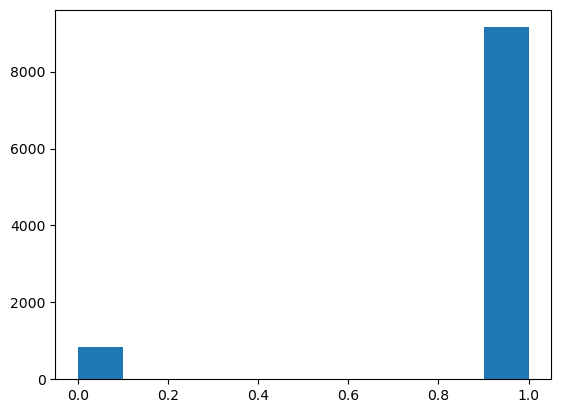

In [38]:
plt.hist(df['Phone'])

In [39]:
df['Techie'].fillna(df['Techie'].mode()[0], inplace=True)

C:\Users\Batman\AppData\Local\Temp\ipykernel_26784\3799330978.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Techie'].fillna(df['Techie'].mode()[0], inplace=True)


(array([8743.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,
        1257.]),
 array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ]),
 <BarContainer object of 10 artists>)

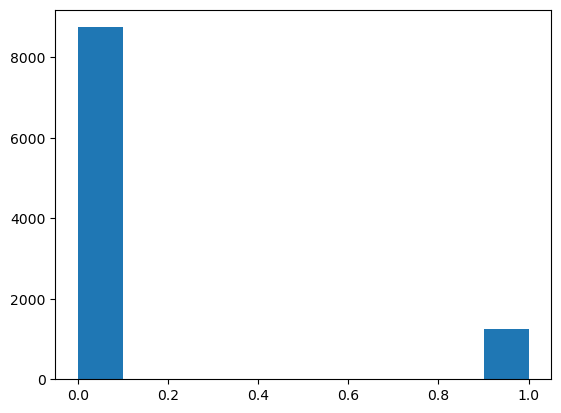

In [40]:
plt.hist(df['Techie'])

In [41]:
df['TechSupport'].fillna(df['TechSupport'].mode()[0], inplace=True)

C:\Users\Batman\AppData\Local\Temp\ipykernel_26784\978077667.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TechSupport'].fillna(df['TechSupport'].mode()[0], inplace=True)


(array([8743.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,
        1257.]),
 array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ]),
 <BarContainer object of 10 artists>)

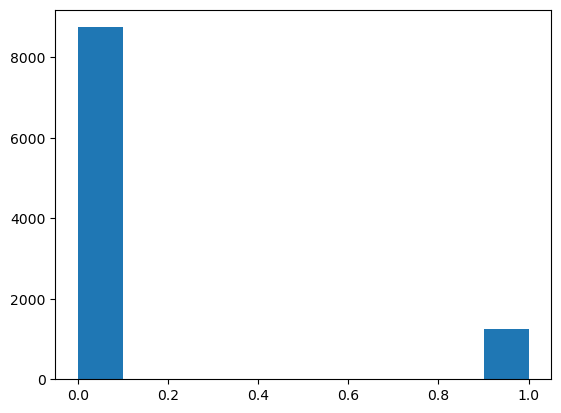

In [42]:
plt.hist(df['Techie'])

In [43]:
df.isnull().sum() #All missing values have been handled 

Unnamed: 0              0
CaseOrder               0
Customer_id             0
Interaction             0
City                    0
State                   0
County                  0
Zip                     0
Lat                     0
Lng                     0
Population              0
Area                    0
Timezone                0
Job                     0
Children                0
Age                     0
Education               0
Employment              0
Income                  0
Marital                 0
Gender                  0
Churn                   0
Outage_sec_perweek      0
Email                   0
Contacts                0
Yearly_equip_failure    0
Techie                  0
Contract                0
Port_modem              0
Tablet                  0
InternetService         0
Phone                   0
Multiple                0
OnlineSecurity          0
OnlineBackup            0
DeviceProtection        0
TechSupport             0
StreamingTV             0
StreamingMov

<Axes: >

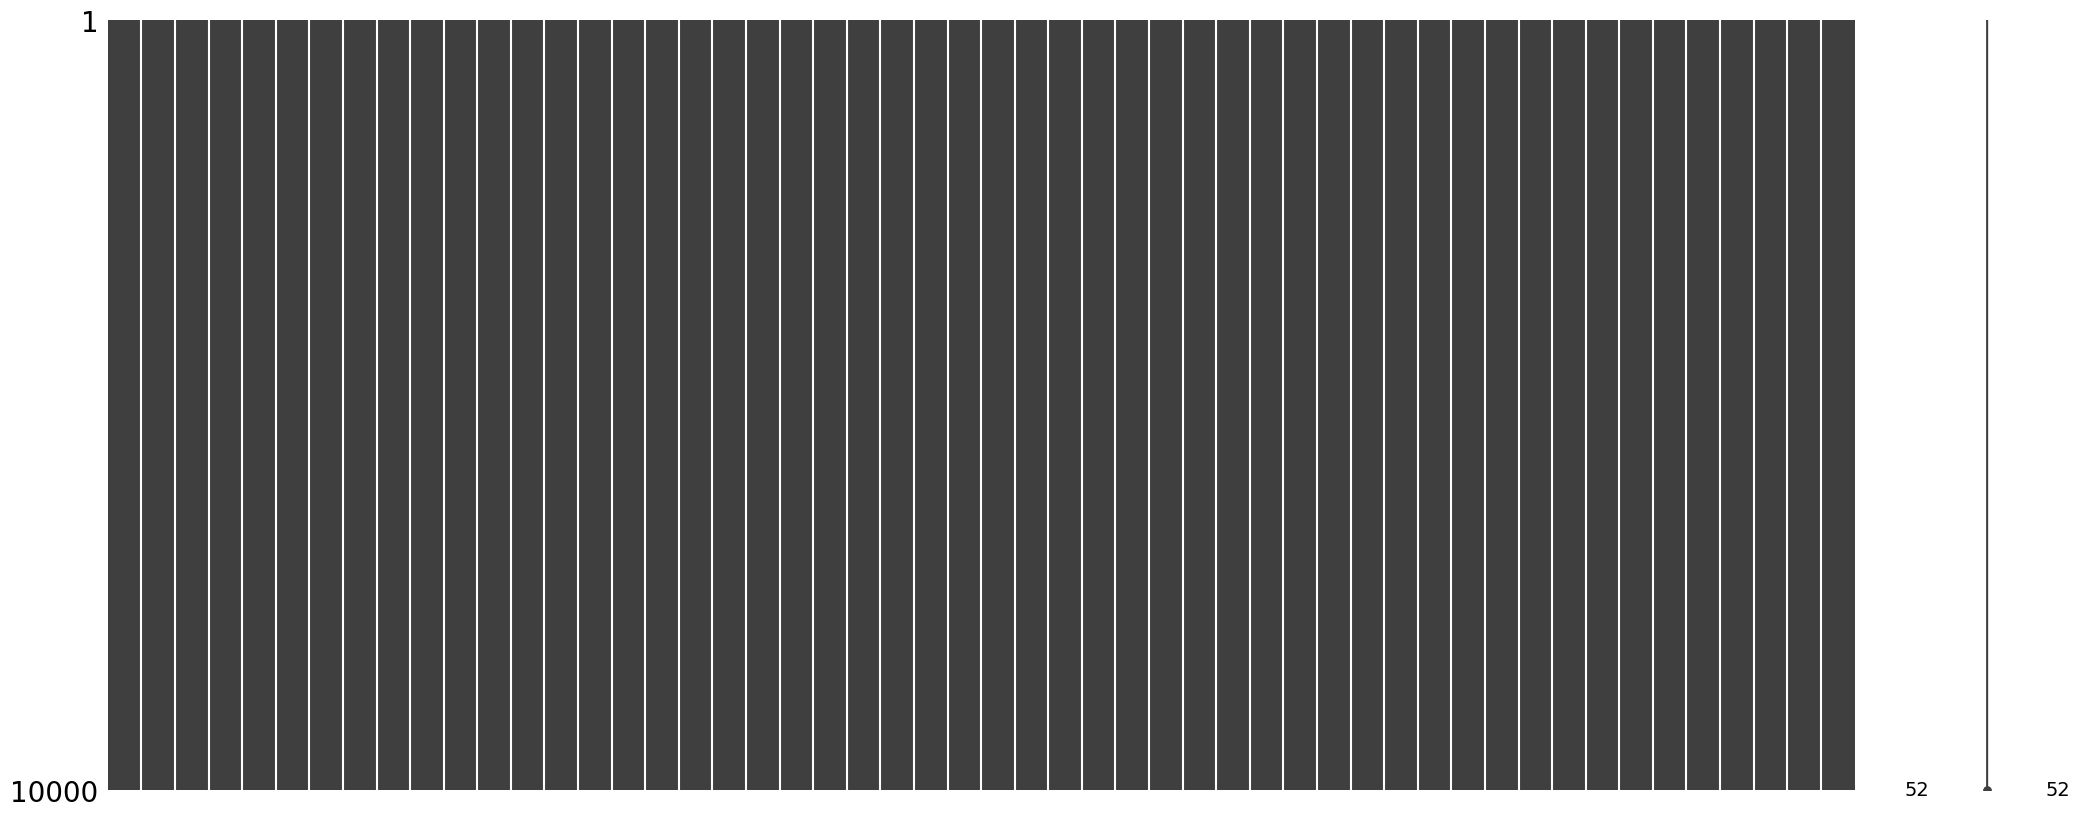

In [44]:
msno.matrix(df) #Visualization of data with all missing values handled. 

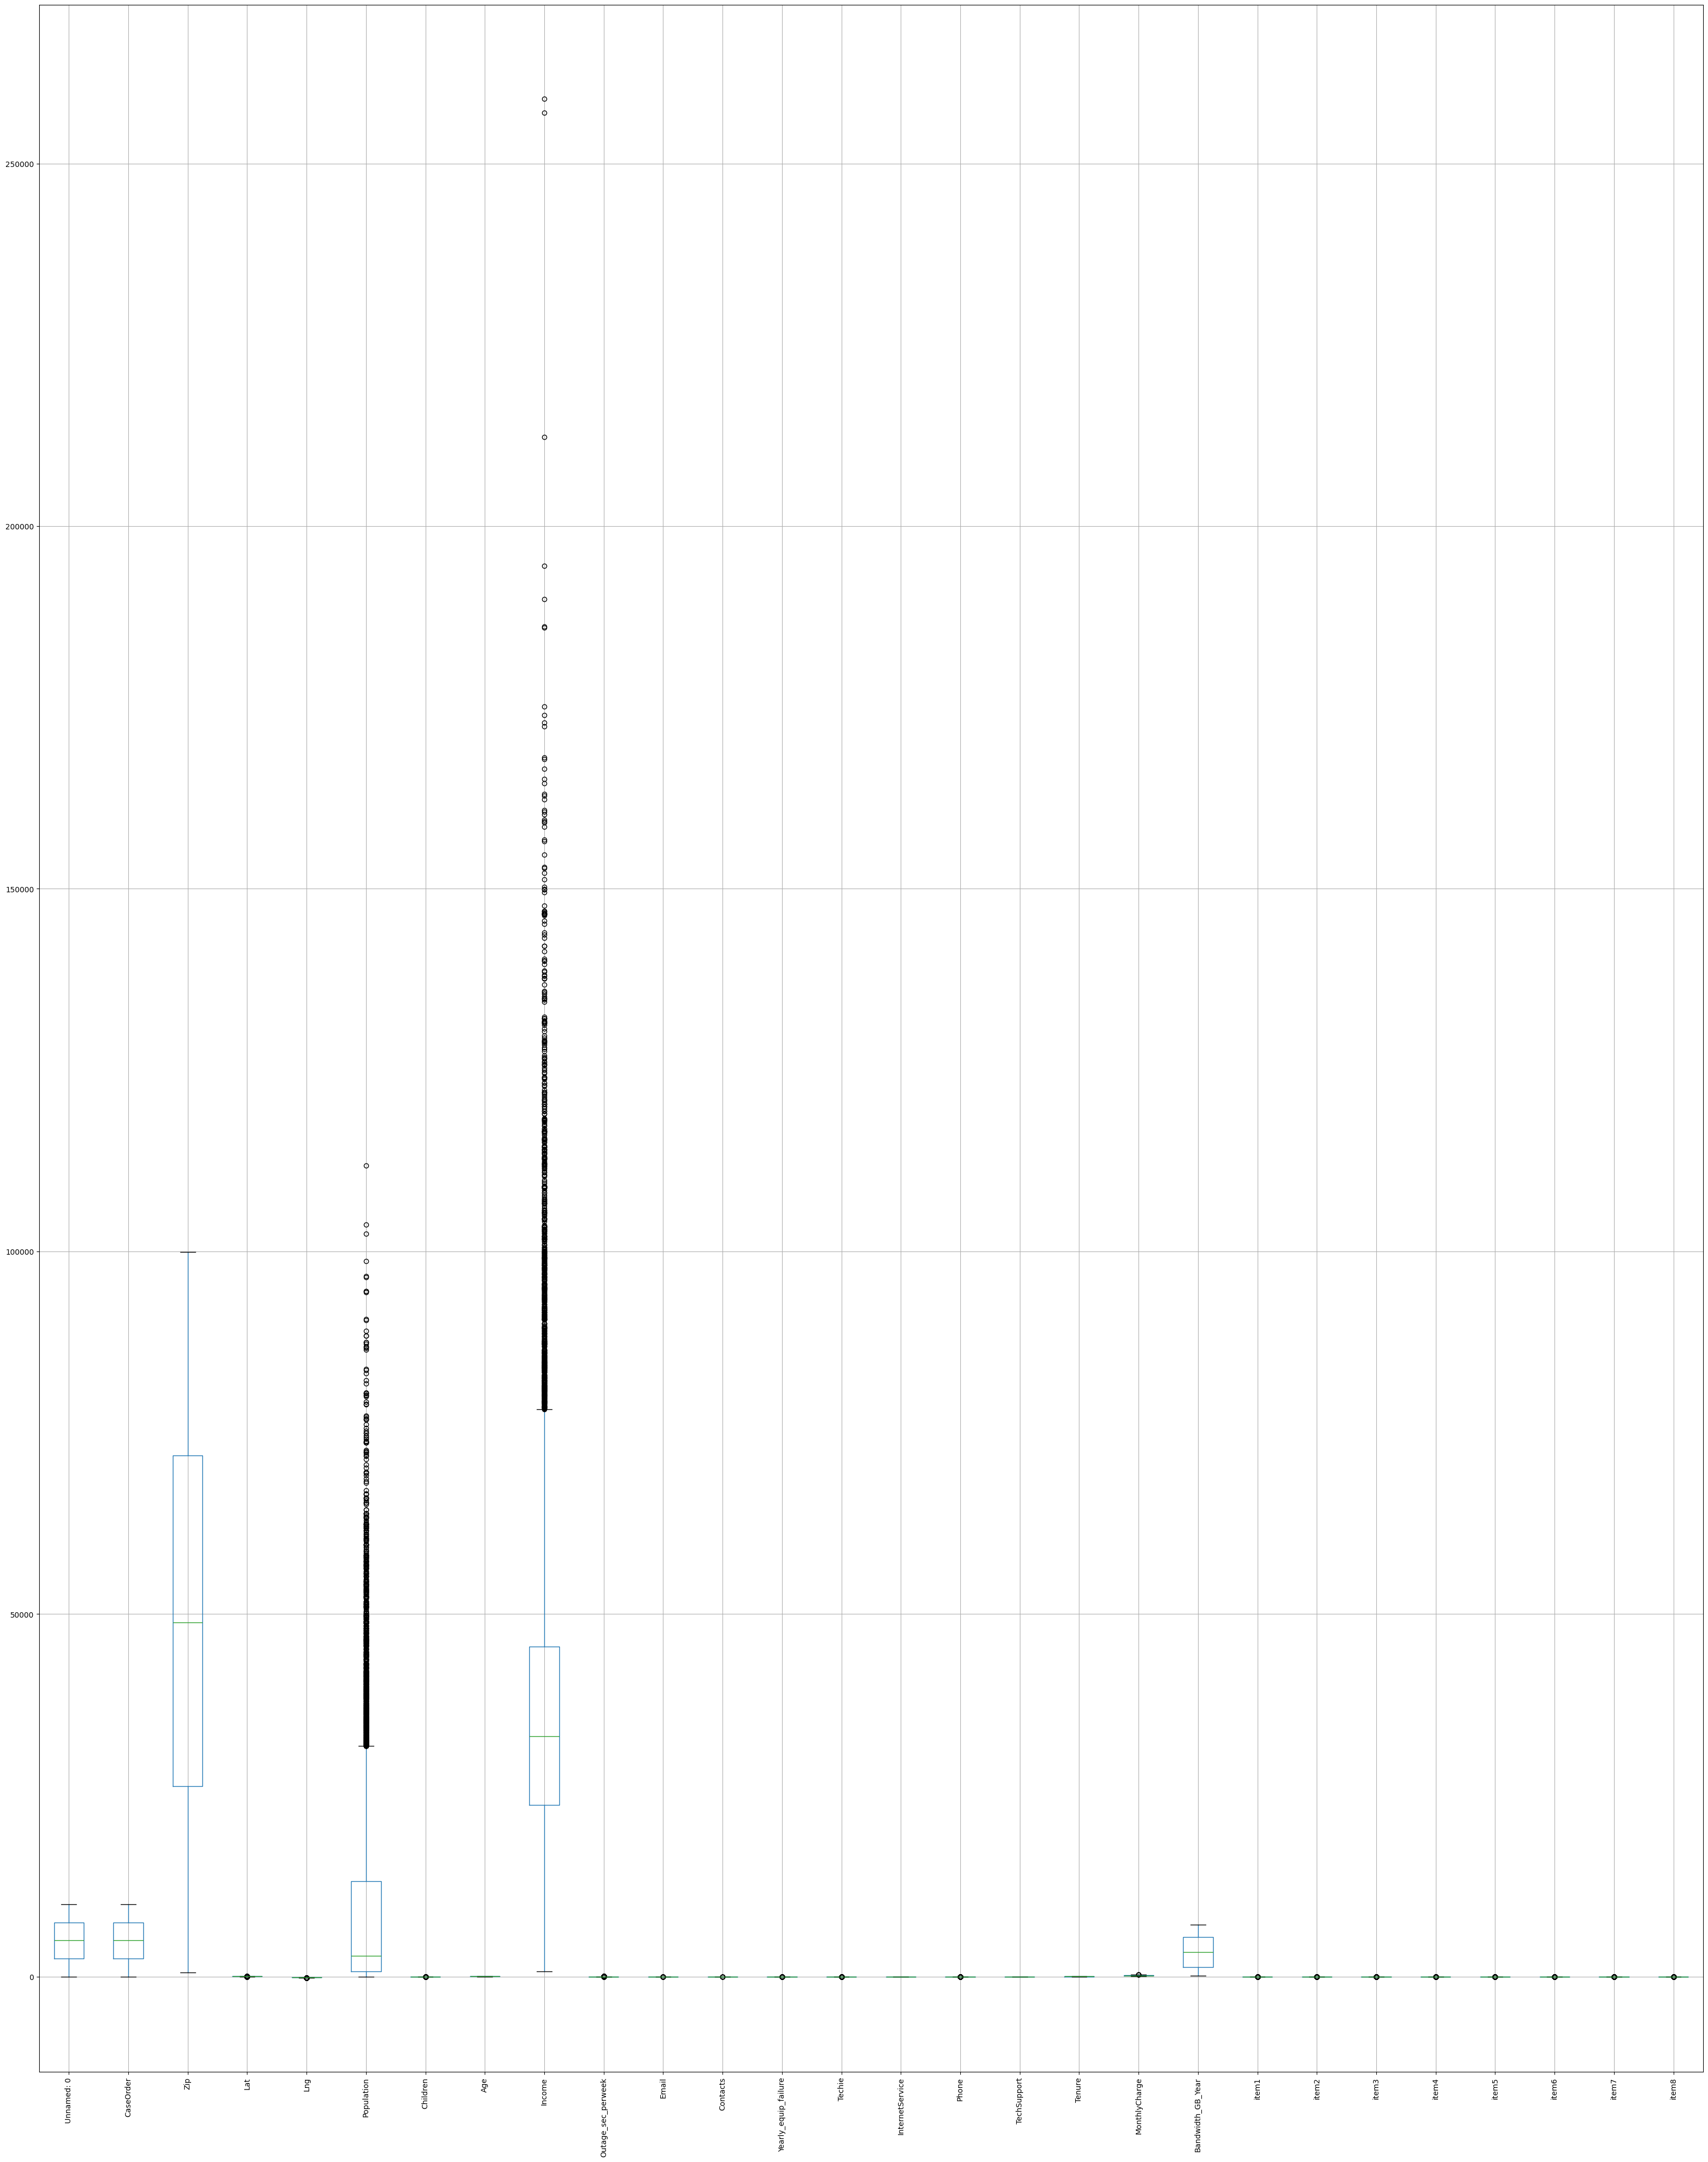

In [45]:
plt.figure(figsize=(40, 50))  
df.boxplot()
plt.xticks(rotation=90)  
plt.show()  #Displays a boxplot for each numerical column. Every plot that has a dot on it has outliers.

In [46]:
numeric_columns = df.select_dtypes(include=['int64', 'float64']).columns  

outliers_dict = {}  # Creating a dictionary to store the count of outliers per column

# I decided to search for outliers in each column all at once instead ov individually. This line loops through each numeric column
for col in numeric_columns:
    Q1 = df[col].quantile(0.25)  
    Q3 = df[col].quantile(0.75)  
    IQR = Q3 - Q1  
    
    # Calculates the lower and upper bounds for outliers
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Finds the outliers
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    
    # Counts the number of outliers for this column
    outliers_count = outliers.shape[0]  # Number of rows (outliers)
    
    # If there are outliers, add them to the dictionary
    if outliers_count > 0:
        outliers_dict[col] = outliers_count

# Prints the outliers count per column
print(outliers_dict)

{'Lat': 158, 'Lng': 273, 'Population': 937, 'Children': 451, 'Income': 759, 'Outage_sec_perweek': 539, 'Email': 38, 'Contacts': 8, 'Yearly_equip_failure': 94, 'Techie': 1257, 'Phone': 846, 'MonthlyCharge': 5, 'item1': 442, 'item2': 445, 'item3': 418, 'item4': 433, 'item5': 422, 'item6': 413, 'item7': 454, 'item8': 426}


In [64]:
df.to_csv('cleaned_data.csv', index=False)

In [65]:
!jupyter nbconvert --to script ChurnData.ipynb

[NbConvertApp] Converting notebook ChurnData.ipynb to script
[NbConvertApp] Writing 6265 bytes to ChurnData.py


In [49]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler #imports necessary libraries for PCA


In [58]:
continuous_columns = ['Population', 'Income', 'Outage_sec_perweek', 'Yearly_equip_failure', 'Tenure', 'MonthlyCharge', 'Bandwidth_GB_Year'] #ensures that only continuous numeric columns are used for PCA
df_continuous = df[continuous_columns]

In [59]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_continuous) #Normalizes numerical data
pca = PCA()
pca.fit(scaled_data) #Computes the principal components, calculates explained variance

PCA()

In [60]:
print(f"Total number of principal components: {pca.n_components_}")

Total number of principal components: 7


In [62]:
# Create a loading matrix dataframe
loadings = pd.DataFrame(
    pca.components_.T,  # transpose so features are rows
    columns=[f'PC{i+1}' for i in range(pca.n_components_)],
    index=continuous_columns
)

# Display the loading matrix
print("Principal Component Loading Matrix:")
print(loadings)

Principal Component Loading Matrix:
                           PC1       PC2       PC3       PC4       PC5  \
Population            0.000086 -0.062190 -0.660547 -0.275819  0.695453   
Income                0.006007 -0.001259  0.118452  0.877736  0.459675   
Outage_sec_perweek    0.022535  0.705442 -0.000303  0.012698  0.076849   
Yearly_equip_failure  0.015689  0.065113  0.730511 -0.391584  0.542854   
Tenure                0.705253 -0.058468 -0.001226  0.001768 -0.005823   
MonthlyCharge         0.045616  0.700505 -0.126249  0.000834 -0.065898   
Bandwidth_GB_Year     0.706929 -0.010787 -0.007759 -0.000957 -0.008426   

                           PC6       PC7  
Population           -0.008909 -0.000506  
Income               -0.064880  0.000940  
Outage_sec_perweek    0.704114  0.000031  
Yearly_equip_failure -0.117611 -0.002552  
Tenure                0.036641 -0.705563  
MonthlyCharge        -0.696162 -0.047839  
Bandwidth_GB_Year    -0.010915  0.707025  


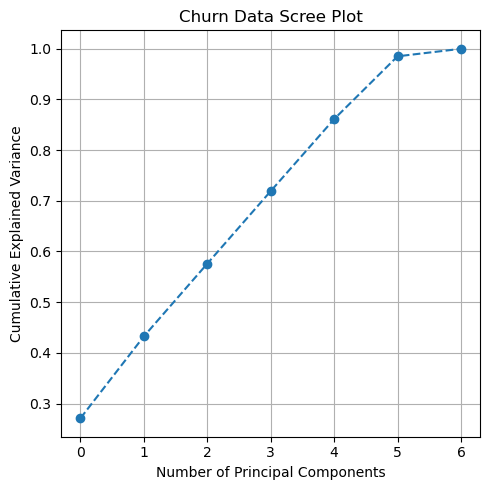

In [63]:
plt.figure(figsize=(5,5))
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o', linestyle='--')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Churn Data Scree Plot')
plt.grid(True)
plt.tight_layout()
plt.show()